In [ ]:
import torch

# Ready-made building blocks for constructing neural networks
import torch.nn as nn
import torch.nn.functional as F

# Optimizers — algorithms designed to speed up and improve the efficiency of gradient descent
import torch.optim as optim

# For explaining the principles of convolutional neural networks
import torch.backends.cudnn as cudnn

# Access to ready-made datasets, including MNIST
from torchvision import datasets

# Transformations. For now we only need ToTensor()
from torchvision import transforms

# Combining data into batches, shuffling data during training, parallel data loading
from torch.utils.data import DataLoader

# NumPy. Not directly needed for neural network development;
# in this notebook it is used only for data visualization
import numpy as np

# Matplotlib. Also visualization
import matplotlib.pyplot as plt
# Utility functionality
import os
import time
import datetime

# Progress bar
from tqdm.auto import tqdm

import warnings
# Suppress the warning about hardware and software compatibility requirements
warnings.filterwarnings('ignore', category=UserWarning)
# Suppress the warning about the need to update methods
warnings.filterwarnings('ignore', category=DeprecationWarning)
# You could simply use warnings.filterwarnings('ignore') without specifying the category,
# but that's not a very good practice and may lead to subtle bugs in the code

# torchviz is not included in Kaggle's standard package set, so we need to use the "%pip install" directive
%pip install torchviz
# Visualization of neural network structure
from torchviz import make_dot

In [ ]:
# Check for the MNIST dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
print(torch.cuda.is_available())

# GPU characteristics
if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.current_device())
    print(torch.cuda.device(torch.cuda.current_device()))
    print(torch.cuda.get_device_name(0))

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

False
Using cpu device


In [ ]:
# You can also try transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# using pre-calculated constants for MNIST (https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457)
transform = transforms.ToTensor()

# Training dataset
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)

# Test dataset
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# The larger the batch_size, the faster the training process, but the worse the feedback, because
# the backpropagation process is triggered less frequently
# shuffle=True -> data will be fed in a different order each time. Useful for training
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

# batch_size can be larger here; it no longer affects accuracy
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 364kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.44MB/s]

Train: 60000, Test: 10000


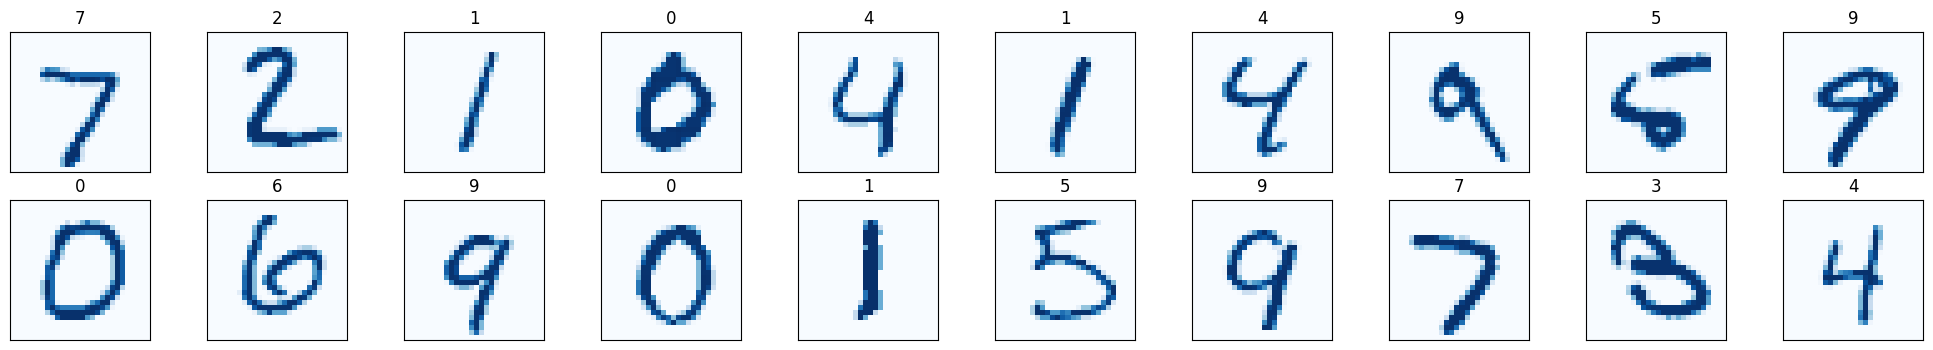

In [ ]:
# If you use train_loader instead of test_loader, the images below
# will change periodically due to shuffling (shuffle=True)
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    # If the colors in the illustrations below don't quite match
    # your sense of beauty, experiment with cmap :)
    ax.imshow(np.squeeze(images[idx]), cmap='Blues')
    ax.set_title(str(labels[idx].item()))

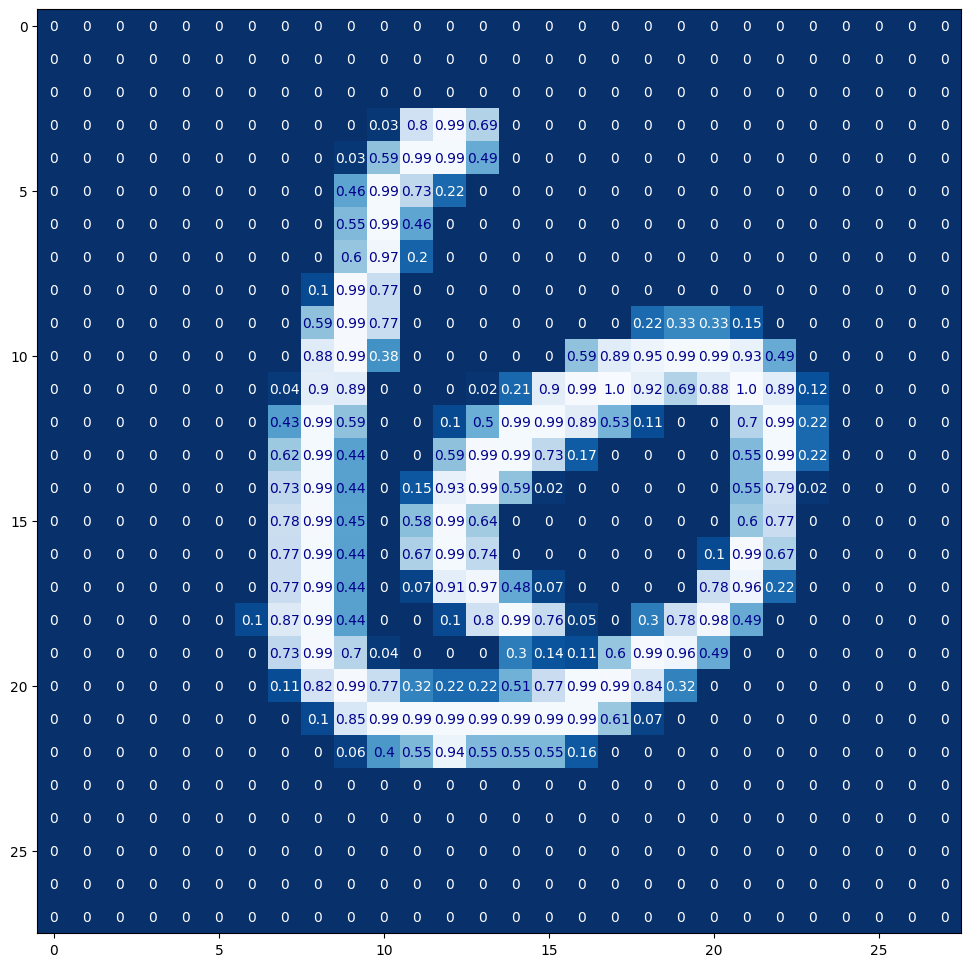

In [ ]:
img = np.squeeze(images[11])

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)

# Note that both here and above the "Blues" colormap is used,
# but adding "_r" inverts the colors. Handy!
ax.imshow(img, cmap='Blues_r')
width, height = img.shape

threshold = img.max()/2.5

for x in range(width):
    for y in range(height):
        val = round(img[x][y], 2) if img[x][y] != 0 else 0

        # Choose font color
        color = 'white' if img[x][y] < threshold else 'darkblue'

        # Display the cell
        ax.annotate(str(val), xy=(y, x), horizontalalignment='center', verticalalignment='center', color=color)


In [ ]:
# A neural network in PyTorch must inherit from nn.Module and have
# a 'forward' method that returns the model architecture
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        # Besides Sequential, you can use ModuleList and ModuleDict, but then the layer
        # interaction logic must be defined in the 'forward' method
        # All layers inside Sequential will be automatically connected sequentially,
        # perfect for a perceptron. Slightly simplifies the syntax
        self.layers = nn.Sequential(

            # Converts the input rectangular image into a long one-dimensional tensor
            # without touching the batch axis
            nn.Flatten(),

            # Input layer. The number of inputs corresponds to the image resolution.
            # Linear = a "regular" neural network layer
            nn.Linear(28 * 28, 800),

            # A bit of nonlinear neural magic — the activation function. ReLU(x) = max(0, x).
            # Without this element the entire neural network would simply become a linear regression method
            nn.ReLU(),

            # At each training step, a portion of neurons from the previous layer can be disabled to prevent overfitting
            nn.Dropout(p=0.3),

            # Hidden layer
            nn.Linear(800, 800),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Output layer. The number of inputs equals the number of outputs from the previous layer,
            # and the number of outputs corresponds to the number of classes into which we classify the images
            nn.Linear(800, 10)
            # This is the perfect place for the softmax activation function,
            # but it's already built into CrossEntropyLoss (see below)
        )

    def forward(self, x):
        return self.layers(x)

# Don't forget to use the GPU
model = Perceptron().to(device)

print(f"\nModel structure: {model}\n\n")

# If you want to see what's inside the model, uncomment the code below
# for name, param in model.named_paramete


Model structure: Perceptron(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=800, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=800, out_features=800, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=800, out_features=10, bias=True)
  )
)




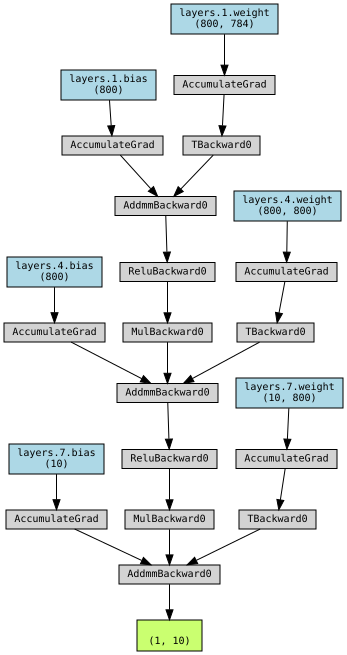

In [ ]:
# We feed a test tensor into our neural network so that PyTorchViz can analyze its internal structure
x = torch.randn(1, 28 * 28).to(device)

make_dot(model(x), params=dict(model.named_parameters()))

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Number of epochs
n_epochs = 32

# Empty list for the future plot
train_loss_curve = []

def model_train():
    # Enable specific layers (Dropout, BatchNorm) used only during training. Even if such layers are absent,
    # still use model.train() so that later, when adding them, you won't have to hunt for bugs
    model.train()

    # Measure the training duration
    start = time.time()

    # Create a progress bar
    pbar = tqdm(range(1, n_epochs + 1))

    for epoch in pbar:
        train_loss = 0.0  # Monitor the loss

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Clear old gradients. You can also work with gradient accumulation, but that trick is not for this (standard) situation
            optimizer.zero_grad()

            # Forward pass, the model processes data using current parameters
            outputs = model(images)

            # Calculate the loss
            loss = criterion(outputs, labels)

            # Compute new gradients. Under the hood: backpropagation = computing partial derivatives with respect to each parameter
            loss.backward()

            # Update all model weights
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        # Calculate the average loss for the epoch
        train_loss = train_loss/len(train_loader.dataset)
        train_loss_curve.append(train_loss)
        pbar.set_description(f'Epoch {epoch}  \tTraining Loss: {train_loss:.4f}')

    end = time.time()
    print(f"\nElapsed time: {str(datetime.timedelta(seconds=round(end-start)))}")

model_train()

  0%|          | 0/32 [00:00<?, ?it/s]


Elapsed time: 0:38:02


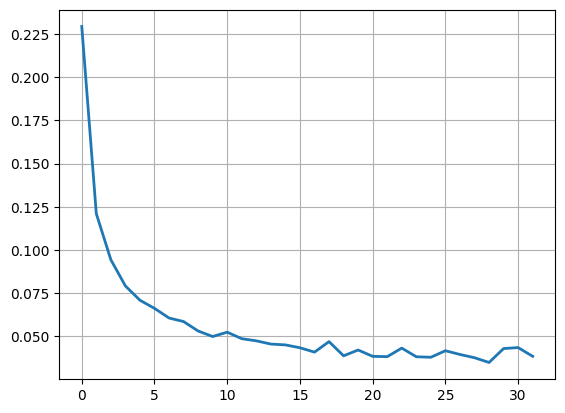

In [ ]:
plt.plot(train_loss_curve, linewidth=2)
plt.grid(True)
plt.show()

In [ ]:
def model_eval():
    # Disable Dropout and BatchNorm layers used only during training.
    # Just as with model.train(), always switch the model to eval()
    model.eval()

    correct = 0
    total = 0

    # Disable backward pass and gradient computation, saving memory and processing time
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

model_eval()

Accuracy: 98.17%


In [ ]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 1276810


In [ ]:
# Save only the model weights
torch.save(model.state_dict(), 'model_weights.pth')

# You can save the entire model (both structure and weights), but this is not recommended
# torch.save(model, 'full_model.pth')

In [ ]:
model.load_state_dict(torch.load('model_weights.pth'))

<All keys matched successfully>

In [ ]:
# Locally connected layer class. PyTorch does not have an implementation of such a layer, so we implement the logic ourselves
class LocallyConnected2d(nn.Module):
    def __init__(self, in_channels, out_channels, input_height, input_width, kernel=3, stride=1):
        super().__init__()
        # Kernel size
        self.kernel = kernel

        # Stride step
        self.stride = stride

        # There should also be padding here to allow preserving the image size, as in "real" CNNs, but for our educational example it'll do
        self.out_height = (input_height - kernel) // stride + 1
        self.out_width = (input_width - kernel) // stride + 1

        # Kaiming initialization. You could also use the more straightforward nn.init.kaiming_normal_,
        # but for our non-standard architecture additional code would be needed
        self.weight = nn.Parameter(torch.randn(self.out_height, self.out_width, out_channels, in_channels * kernel ** 2) * (2.0 / (in_channels * kernel ** 2)) ** 0.5) # bias should be initialized with zeros
        self.bias = nn.Parameter(torch.zeros(self.out_height, self.out_width, out_channels))

        # If the code below isn't entirely clear — don't worry, this is just a concept
        # intended to demonstrate that behind every PyTorch method lies concrete mathematics,
        # and that sometimes you can implement the functionality you need by bypassing the standard approaches
    def forward(self, x):
        # Slide a kernel × kernel window across height (axis 2) and width (axis 3) with the given stride
        # We get all patches — cropped image fragments matching the kernel size, to which weights will be applied
        patches = x.unfold(2, self.kernel, self.stride).unfold(3, self.kernel, self.stride)

        # Rearrange axes: move spatial coordinates (h, w) to the second and third positions,
        # and channels and patch pixels to the end. contiguous() rearranges data in memory to match the new order
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()

        # Flatten channels and pixels of each patch into one long vector
        # Now each patch is simply a list of numbers ready to be multiplied by weights
        patches = patches.view(x.size(0), self.out_height, self.out_width, -1)

        # For each position (h, w), multiply its patch by its own weights — not shared across the entire map
        # This is exactly where local connectivity lies: each position has its own independent set of weights
        out = torch.einsum('bhwi,hwoi->bhwo', patches, self.weight) + self.bias

        # Return channels to the second position — bring the tensor back to the standard format (batch, channels, height, width)
        # This is needed so that the next layer receives data in the axis order expected by PyTorch
        return out.permute(0, 3, 1, 2)

class LocallyConnectedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.lc1 = LocallyConnected2d(1, 16, 28, 28)
        self.lc2 = LocallyConnected2d(16, 32, 13, 13)
        self.fc1 = nn.Linear(32 * 5 * 5, 128)  #  "Regular" fully connected layer for image classification 800 -> 128
        self.fc2 = nn.Linear(128, 10)  # "Regular" fully connected output layer 128 -> 10

    def forward(self, x):
        x = self.lc1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)  # Take the maximum in each 2×2 window, size is halved. We won't write max_pool2d ourselves; it's a standard PyTorch layer

        # There may be pixel loss here with odd image dimensions (due to integer division in the LocallyConnected2d code), but for MNIST everything works
        x = self.lc2(x)         # Second locally connected layer, 32 output channels
        x = F.relu(x)
        x = F.max_pool2d(x, 2)  # Again halve the size (11//2 = 5)

        x = x.flatten(1)        # Flatten 32×5×5 into a flat tensor of length 800, merging all tensor axes except the zeroth
        x = self.fc1(x)         # 128 fully connected neurons, 800 → 128
        x = F.relu(x)

        x = self.fc2(x)         # Fully connected layer 128 → 10
        return x                # Return logits (Softmax will be applied later, when computing the loss function)

In [ ]:
model = LocallyConnectedNet().to(device)

print(f"\nModel structure: {model}\n\n")
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: LocallyConnectedNet(
  (lc1): LocallyConnected2d()
  (lc2): LocallyConnected2d()
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)




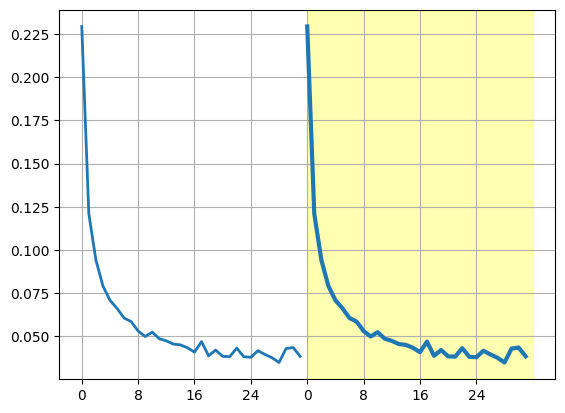

In [ ]:
# A bit of trickery so that the right half of the plot also visually counts from zero
x_positions = list(range(0, n_epochs)) + list(range(n_epochs, 2 * n_epochs))

segment1 = train_loss_curve[:n_epochs]
# Corrected: segment2 should have the same length as segment1 if it's meant to visually repeat the curve
segment2 = train_loss_curve[:n_epochs]

x_segment1 = x_positions[:n_epochs]
x_segment2 = x_positions[n_epochs:]

plt.plot(x_segment1, segment1, linewidth=2, color='C0')
plt.plot(x_segment2, segment2, linewidth=3, color='C0')

x_ticks = list(range(0, 2 * n_epochs, n_epochs // 4))
x_labels = [str(i % n_epochs) for i in x_ticks]

plt.xticks(x_ticks, x_labels)

# Highlight the second half of the plot
plt.axvspan(n_epochs, 2 * n_epochs, color='yellow', alpha=0.3)

plt.grid(True)
plt.show()

In [ ]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 773418


In [ ]:
class CNN_Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = CNN_Net().to(device)

print(f"\nModel structure: {model}\n\n")
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: CNN_Net(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=800, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)




In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# We'll discuss this line a little below
cudnn.benchmark = True

model_train()

  0%|          | 0/32 [00:00<?, ?it/s]


Elapsed time: 0:19:14


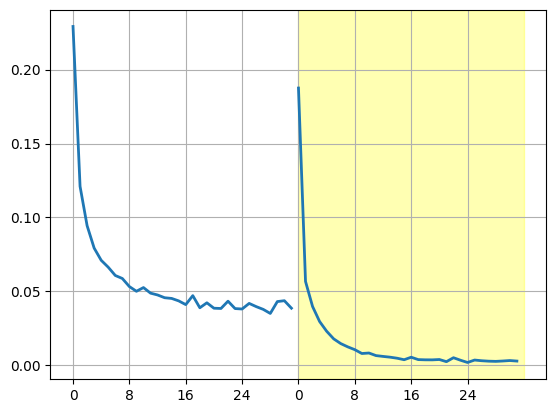

In [ ]:
x_positions = list(range(0, n_epochs)) + list(range(n_epochs, 2 * n_epochs))

segment1_x = x_positions[:n_epochs]
segment1_y = train_loss_curve[:n_epochs]

segment2_x = x_positions[n_epochs:2*n_epochs]
segment2_y = train_loss_curve[n_epochs:2*n_epochs]

# C0 - the default color is #0 for all plots,
# otherwise Matplotlib will start coloring the plots
plt.plot(segment1_x, segment1_y, linewidth=2, color='C0')
plt.plot(segment2_x, segment2_y, linewidth=2, color='C0')

x_ticks = list(range(0, 2 * n_epochs, n_epochs // 4))
x_labels = [str(i % n_epochs) for i in x_ticks]

plt.xticks(x_ticks, x_labels)

# Highlight the second half of the plot
plt.axvspan(n_epochs, 2 * n_epochs, color='yellow', alpha=0.3)

plt.grid(True)
plt.show()

In [ ]:
model_eval()

Accuracy: 99.06%


In [ ]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 108618


In [ ]:
import torch

# Define example values for the variables involved in convolution
B = 1                           # Batch size
C_in = 1                        # Input channels
C_out = 1                       # Output channels
H_in = 28                       # Input height
W_in = 28                       # Input width
KH = 3                          # Kernel height
KW = 3                          # Kernel width
stride = 1                      # Stride

# Calculate output dimensions
H_out = (H_in - KH) // stride + 1
W_out = (W_in - KW) // stride + 1

# Initialize input, kernel, and output tensors with example data
input = torch.randn(B, C_in, H_in, W_in)      # Example input tensor
kernel = torch.randn(C_out, C_in, KH, KW)     # Example kernel tensor
output = torch.zeros(B, C_out, H_out, W_out)  # Initialize output tensor

for b in range(B):                           # Batches
    for co in range(C_out):                  # Output channels
        for i in range(H_out):               # Output height
            for j in range(W_out):           # Output width
                for ci in range(C_in):       # Input channels
                    for ki in range(KH):     # Kernel height
                        for kj in range(KW): # Kernel width
                            output[b, co, i, j] += (input[b, ci, i * stride + ki, j * stride + kj] * kernel[co, ci, ki, kj])

print("Manual convolution completed successfully.")
print(f"Output shape: {output.shape}")

Manual convolution completed successfully.
Output shape: torch.Size([1, 1, 26, 26])


In [ ]:
cudnn.benchmark = True

In [ ]:
import torch.nn.functional as F

# Perform convolution using F.conv2d
# Ensure input, kernel, and stride are consistent with the manual implementation

# The input, kernel, and stride are already defined and are in scope from cell sFN37kbGK3r-
# input: torch.randn(B, C_in, H_in, W_in)
# kernel: torch.randn(C_out, C_in, KH, KW)
# stride: stride (integer)

output_torch = F.conv2d(input, kernel, stride=stride)

print(f"Output shape from F.conv2d: {output_torch.shape}")

# Compare the outputs
# Use torch.allclose for numerical stability due to potential floating point differences
if torch.allclose(output, output_torch, atol=1e-6):
    print("Manual convolution output matches F.conv2d output!")
else:
    print("Manual convolution output DOES NOT match F.conv2d output.")
    # Optionally, print differences if they don't match exactly
    # print(f"Max absolute difference: {(output - output_torch).abs().max()}")

Output shape from F.conv2d: torch.Size([1, 1, 26, 26])
Manual convolution output matches F.conv2d output!


### Implementing Custom Backward Pass for Convolution

In [ ]:
import torch

# We'll use the same parameters for consistency with the manual forward pass
# These variables (B, C_in, C_out, H_in, W_in, KH, KW, stride, H_out, W_out)
# are assumed to be defined in a previous cell (sFN37kbGK3r-)

class CustomConv2d(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input, kernel, stride):
        # Ensure inputs are contiguous to avoid issues with strides
        input = input.contiguous()
        kernel = kernel.contiguous()

        # Get dimensions
        B, C_in, H_in, W_in = input.shape
        C_out, _, KH, KW = kernel.shape

        # Calculate output dimensions
        H_out = (H_in - KH) // stride + 1
        W_out = (W_in - KW) // stride + 1

        # Initialize output tensor
        output = torch.zeros(B, C_out, H_out, W_out, device=input.device, dtype=input.dtype)

        # Manual convolution logic
        for b in range(B):
            for co in range(C_out):
                for i in range(H_out):
                    for j in range(W_out):
                        for ci in range(C_in):
                            for ki in range(KH):
                                for kj in range(KW):
                                    output[b, co, i, j] += (
                                        input[b, ci, i * stride + ki, j * stride + kj] *
                                        kernel[co, ci, ki, kj]
                                    )

        # Save tensors for backward pass
        ctx.save_for_backward(input, kernel)
        ctx.stride = stride

        return output

    @staticmethod
    def backward(ctx, grad_output):
        input, kernel = ctx.saved_tensors
        stride = ctx.stride

        B, C_in, H_in, W_in = input.shape
        C_out, _, KH, KW = kernel.shape
        _, _, H_out, W_out = grad_output.shape

        grad_input = torch.zeros_like(input)
        grad_kernel = torch.zeros_like(kernel)

        # Manual backward pass logic
        for b in range(B):
            for co in range(C_out):
                for i in range(H_out):
                    for j in range(W_out):
                        for ci in range(C_in):
                            for ki in range(KH):
                                for kj in range(KW):
                                    # Gradient with respect to input
                                    grad_input[b, ci, i * stride + ki, j * stride + kj] += (
                                        grad_output[b, co, i, j] *
                                        kernel[co, ci, ki, kj]
                                    )
                                    # Gradient with respect to kernel
                                    grad_kernel[co, ci, ki, kj] += (
                                        grad_output[b, co, i, j] *
                                        input[b, ci, i * stride + ki, j * stride + kj]
                                    )

        return grad_input, grad_kernel, None # None for stride as it's not a tensor requiring gradients

# Helper function to use our custom convolution
def custom_conv2d_op(input, kernel, stride):
    return CustomConv2d.apply(input, kernel, stride)

print("CustomConv2d class defined.")

CustomConv2d class defined.


### Verification of Custom Backward Pass
Let's verify that the custom backward pass correctly computes gradients by comparing them with PyTorch's automatic differentiation results.

### Visualizing Gradients using Heatmaps

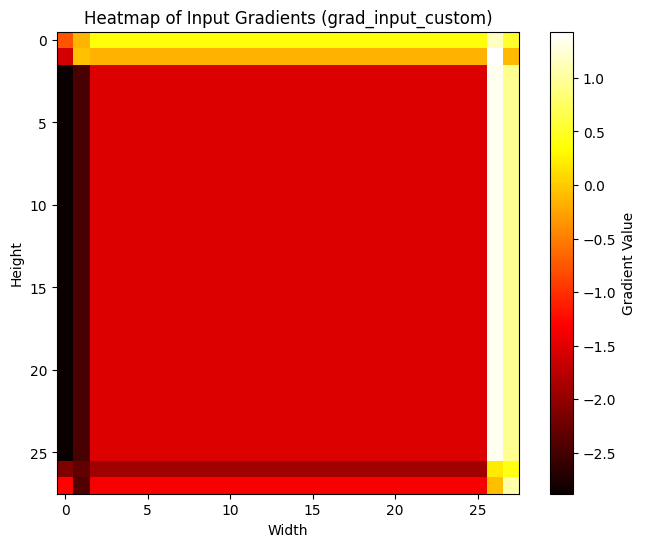

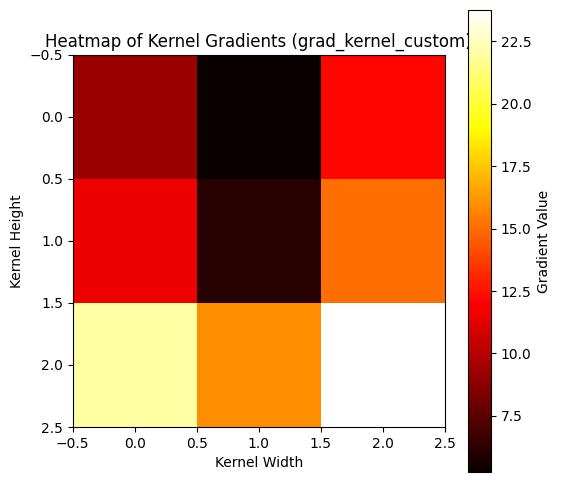

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize grad_input_custom
plt.figure(figsize=(8, 6))
# Assuming B=1, C_in=1 from the example, squeeze to get a 2D image for plotting
if grad_input_custom.dim() == 4 and grad_input_custom.shape[0] == 1 and grad_input_custom.shape[1] == 1:
    grad_input_plot = grad_input_custom.squeeze().cpu().numpy()
elif grad_input_custom.dim() == 2:
    grad_input_plot = grad_input_custom.cpu().numpy()
else:
    # Fallback for other shapes, might need adjustment if C_in > 1
    print("Warning: grad_input_custom has an unexpected shape for simple 2D visualization. Summing across channels.")
    grad_input_plot = grad_input_custom.sum(dim=(0,1)).cpu().numpy()

plt.imshow(grad_input_plot, cmap='hot', interpolation='nearest')
plt.colorbar(label='Gradient Value')
plt.title('Heatmap of Input Gradients (grad_input_custom)')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

# Visualize grad_kernel_custom
plt.figure(figsize=(6, 6))
# Assuming C_out=1, C_in=1 from the example, squeeze to get a 2D image for plotting
if grad_kernel_custom.dim() == 4 and grad_kernel_custom.shape[0] == 1 and grad_kernel_custom.shape[1] == 1:
    grad_kernel_plot = grad_kernel_custom.squeeze().cpu().numpy()
elif grad_kernel_custom.dim() == 2:
    grad_kernel_plot = grad_kernel_custom.cpu().numpy()
else:
    # Fallback for other shapes, might need adjustment if C_out or C_in > 1
    print("Warning: grad_kernel_custom has an unexpected shape for simple 2D visualization. Summing across channels.")
    grad_kernel_plot = grad_kernel_custom.sum(dim=(0,1)).cpu().numpy()

plt.imshow(grad_kernel_plot, cmap='hot', interpolation='nearest')
plt.colorbar(label='Gradient Value')
plt.title('Heatmap of Kernel Gradients (grad_kernel_custom)')
plt.xlabel('Kernel Width')
plt.ylabel('Kernel Height')
plt.show()


In [ ]:
import torch.nn.functional as F

# Re-create input and kernel with requires_grad=True for autograd
# Using the same dimensions as the manual convolution example
input_test = torch.randn(B, C_in, H_in, W_in, requires_grad=True)
kernel_test = torch.randn(C_out, C_in, KH, KW, requires_grad=True)

# --- Test Custom Conv2d ---
output_custom = custom_conv2d_op(input_test, kernel_test, stride)
loss_custom = output_custom.sum() # A simple scalar loss for gradient calculation
loss_custom.backward() # Compute gradients using our custom backward

grad_input_custom = input_test.grad
grad_kernel_custom = kernel_test.grad

input_test.grad = None # Clear gradients for the next test
kernel_test.grad = None

# --- Test F.conv2d (PyTorch's built-in) ---
output_pytorch = F.conv2d(input_test, kernel_test, stride=stride)
loss_pytorch = output_pytorch.sum() # A simple scalar loss for gradient calculation
loss_pytorch.backward() # Compute gradients using PyTorch's autograd

grad_input_pytorch = input_test.grad
grad_kernel_pytorch = kernel_test.grad

# --- Compare Gradients ---
print(f"\nComparing gradients for input:")
if torch.allclose(grad_input_custom, grad_input_pytorch, atol=1e-6):
    print("  Custom input gradients match PyTorch's!")
else:
    print("  Custom input gradients DO NOT match PyTorch's.")
    print(f"  Max absolute difference: {(grad_input_custom - grad_input_pytorch).abs().max()}")

print(f"\nComparing gradients for kernel:")
if torch.allclose(grad_kernel_custom, grad_kernel_pytorch, atol=1e-6):
    print("  Custom kernel gradients match PyTorch's!")
else:
    print("  Custom kernel gradients DO NOT match PyTorch's.")
    print(f"  Max absolute difference: {(grad_kernel_custom - grad_kernel_pytorch).abs().max()}")

print("\nVerification complete.")


Comparing gradients for input:
  Custom input gradients match PyTorch's!

Comparing gradients for kernel:
  Custom kernel gradients match PyTorch's!

Verification complete.
